<a href="https://colab.research.google.com/github/azizamir/Electrofacies-Lithofacies-and-Depositional-Environment-Prediction/blob/main/Electrofacies%20Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electrofacies Classifier

In [ ]:
# ploting, dataframe, and numerical operation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from plotfunc import efplot_data, efplot_val, efplot_test
from jcopml.plot import plot_confusion_matrix, plot_classification_report

# dataset splitting
from sklearn.model_selection import train_test_split

# training
!pip install jcopml
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jcopml.pipeline import num_pipe, cat_pipe
from jcopml.utils import save_model, load_model
from jcopml.plot import plot_missing_value
from jcopml.feature_importance import mean_score_decrease
from sklearn.metrics import f1_score, classification_report

# feature engineering
from jcopml.feature_importance import mean_score_decrease as msd

## Data loading

In [ ]:
df = pd.read_csv("ef_train.csv")

df = df.replace([-999.25, df['GR'].max(), df['DTCO'].max(), df['NPHI'].max()], np.nan)

df.head()

,Depth,Well,Formation,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Electrofacies
0,4600.0,P-2,Jamieson Fm,66.4510,3.8376,3.6067,13.8882,2.5715,81.8708,NaN,2
1,4600.5,P-2,Jamieson Fm,54.4524,4.5844,4.2673,12.1851,2.5604,78.5466,NaN,2
2,4601.0,P-2,Jamieson Fm,51.3234,4.9751,4.4704,12.0860,2.5458,81.6343,NaN,2
3,4601.5,P-2,Jamieson Fm,49.2121,5.1362,4.6478,11.5609,2.5479,78.2709,NaN,2
4,4602.0,P-2,Jamieson Fm,68.4992,4.3777,4.0461,15.9469,2.5307,79.5989,NaN,2


## Data statistics
Target label well distributed

In [ ]:
df.describe()

,Depth,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Electrofacies
count,2995.000000,2752.000000,2953.000000,2948.000000,2904.000000,2829.000000,2662.000000,2468.000000,2995.000000
mean,4962.672287,66.165314,43.498611,27.765264,20.951128,2.654081,68.837401,121.471750,2.491152
std,216.569096,35.172555,180.250196,74.263356,10.938193,0.119257,9.057644,22.403778,1.104209
min,4577.000000,5.377100,0.382200,0.106000,2.085300,1.525400,42.793000,69.261800,0.000000
25%,4775.500000,34.857950,4.396600,4.294575,11.536625,2.629200,62.437400,103.399550,2.000000
50%,4962.500000,65.585350,9.641000,9.460800,20.416250,2.674400,67.121050,117.314650,2.000000
75%,5149.750000,92.777125,25.361700,24.062525,27.414625,2.711300,75.129650,136.881475,4.000000
max,5351.000000,171.265700,1950.000000,1552.880400,57.603600,3.157100,122.791000,234.866500,4.000000


In [ ]:
df.Electrofacies.value_counts()

2    1073
4     810
1     620
3     485
0       7
Name: Electrofacies, dtype: int64

## Missing values checking

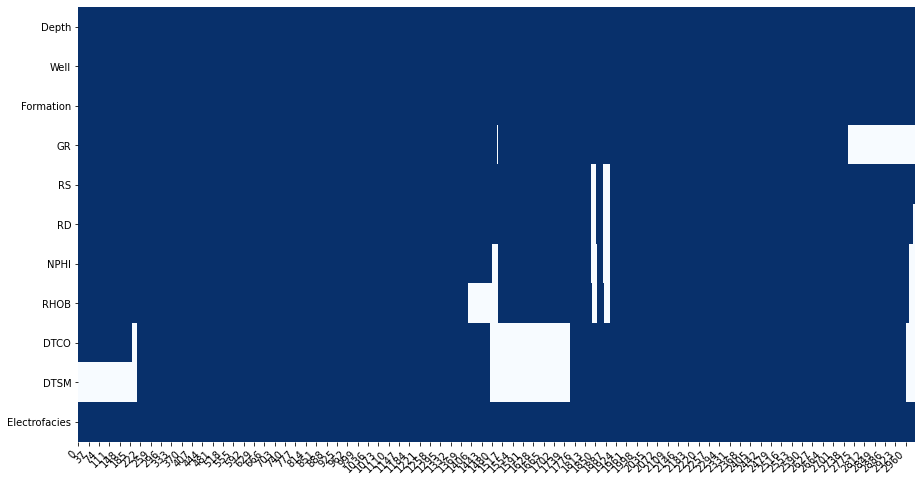

In [ ]:
plot_missing_value(df)

## Training data plotting

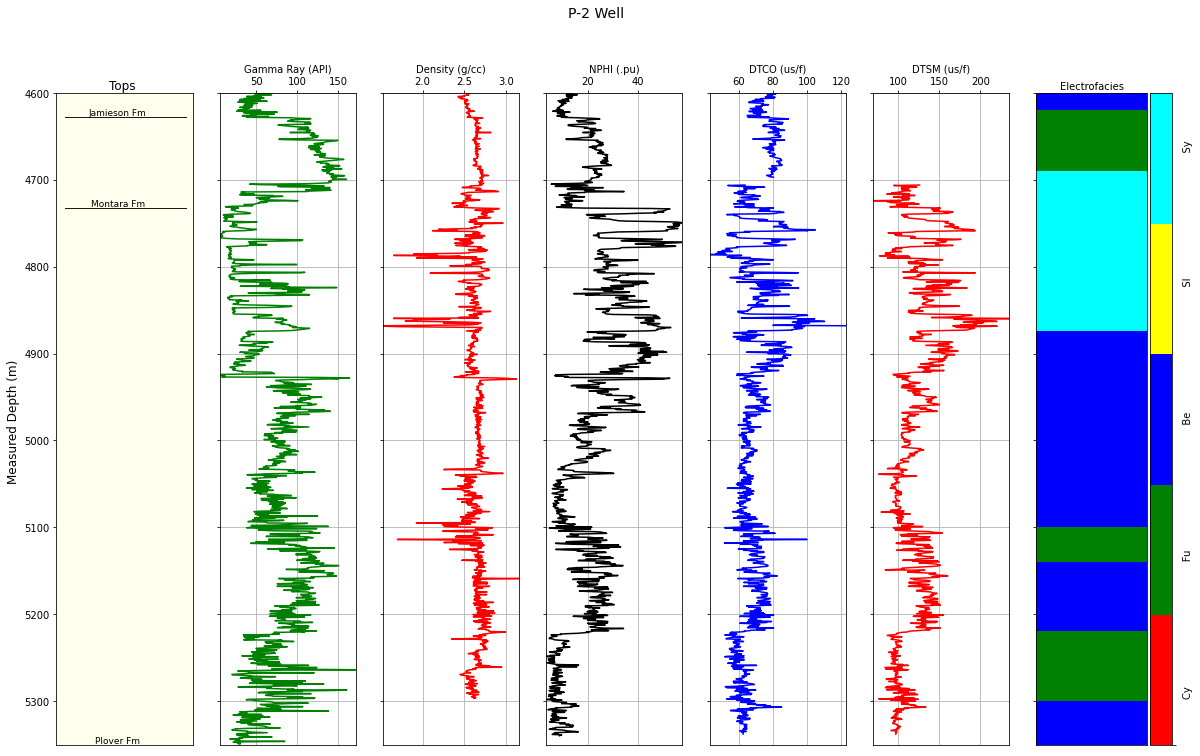

In [ ]:
efplot_data(df, 'P-2')

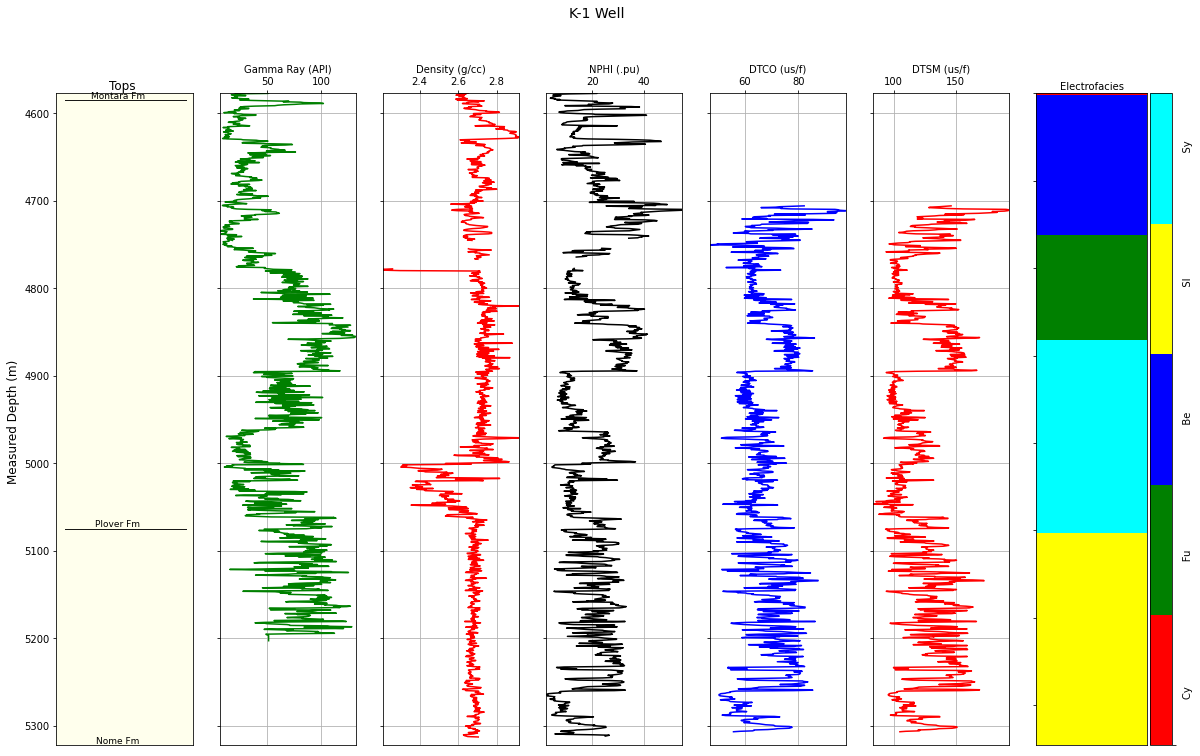

In [ ]:
efplot_data(df, 'K-1')

## Dataset splitting
- Testing GR logs as the only features to predict electrofacies pattern (model error)
- Testing GR logs and formation as the features to predict electrofacies pattern (model error)

In [ ]:
df.columns

Index(['Depth', 'Well', 'Formation', 'GR', 'RS', 'RD', 'NPHI', 'RHOB', 'DTCO',
       'DTSM', 'Electrofacies'],
      dtype='object')

In [ ]:
X = df.drop(columns= ['Depth', 'Well', 'Formation', 'RS', 'Electrofacies'])
y = df.Electrofacies

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2396, 6), (599, 6), (2396,), (599,))

In [ ]:
X.columns

Index(['GR', 'RD', 'NPHI', 'RHOB', 'DTCO', 'DTSM'], dtype='object')

In [ ]:
y

0       2
1       2
2       2
3       2
4       2
       ..
2990    3
2991    3
2992    3
2993    3
2994    3
Name: Electrofacies, Length: 2995, dtype: int64

## Training
- Using KNN, manual numerical_pipeline with simple imputer and standard scaler, 58.9%
- Using KNN, num_pipe, scaling standard, impute mean, GSCV, 76,8%, done - final
- Using KNN, num_pipe, scaling standard, impite meanm GSCV, features = ['GR', 'RD', 'NPHI', 'RHOB', 'DTCO', 'DTSM'], 77.8%, done - final

In [ ]:
X_train.columns

Index(['GR', 'RD', 'NPHI', 'RHOB', 'DTCO', 'DTSM'], dtype='object')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from skopt import BayesSearchCV
from jcopml.tuning import grid_search_params as gsp, random_search_params as rsp, bayes_search_params as bsp

In [ ]:
preprocessor = ColumnTransformer([
                                  ('numeric', num_pipe(scaling= 'standard', impute = 'mean'), X_train.columns)
])

pipeline = Pipeline([
                     ('prep', preprocessor),
                     ('algo', KNeighborsClassifier())
])

model = GridSearchCV(pipeline, gsp.knn_params, cv= 5, n_jobs=-1, verbose=1)
model.fit(X_train, y_train)

print('')                      
print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 5 folds for each of 90 candidates, totalling 450 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 443 out of 450 | elapsed:   14.4s remaining:    0.2s



{'algo__n_neighbors': 3, 'algo__p': 1, 'algo__weights': 'distance'}
1.0 0.7704549408489909 0.7796327212020033


[Parallel(n_jobs=-1)]: Done 450 out of 450 | elapsed:   14.7s finished


### Tuning report

In [ ]:
pd.DataFrame(model.cv_results_).sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algo__n_neighbors,param_algo__p,param_algo__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,0.010388,0.000824,0.016946,0.000379,3,1,distance,"{'algo__n_neighbors': 3, 'algo__p': 1, 'algo__...",0.760417,0.784969,0.770355,0.743215,0.793319,0.770455,0.017755,1
19,0.009642,0.000233,0.019897,0.001998,7,1,distance,"{'algo__n_neighbors': 7, 'algo__p': 1, 'algo__...",0.775000,0.762004,0.747390,0.766180,0.784969,0.767109,0.012625,2
25,0.009669,0.000350,0.021066,0.002735,9,1,distance,"{'algo__n_neighbors': 9, 'algo__p': 1, 'algo__...",0.781250,0.762004,0.747390,0.757829,0.778706,0.765436,0.012818,3
13,0.011417,0.003114,0.019189,0.001656,5,1,distance,"{'algo__n_neighbors': 5, 'algo__p': 1, 'algo__...",0.772917,0.776618,0.764092,0.739040,0.772443,0.765022,0.013622,4
37,0.010330,0.000495,0.022626,0.001160,13,1,distance,"{'algo__n_neighbors': 13, 'algo__p': 1, 'algo_...",0.787500,0.749478,0.734864,0.764092,0.784969,0.764181,0.020256,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,0.013134,0.004814,0.308710,0.005351,27,1.5,uniform,"{'algo__n_neighbors': 27, 'algo__p': 1.5, 'alg...",0.739583,0.705637,0.701461,0.711900,0.709812,0.713679,0.013440,86
86,0.010330,0.000849,0.303538,0.019440,29,1.5,uniform,"{'algo__n_neighbors': 29, 'algo__p': 1.5, 'alg...",0.739583,0.701461,0.693111,0.709812,0.703549,0.709503,0.015961,87
76,0.009518,0.000356,0.046311,0.004055,25,2,uniform,"{'algo__n_neighbors': 25, 'algo__p': 2, 'algo_...",0.733333,0.686848,0.697286,0.709812,0.716075,0.708671,0.015939,88
88,0.010342,0.000626,0.048981,0.002961,29,2,uniform,"{'algo__n_neighbors': 29, 'algo__p': 2, 'algo_...",0.722917,0.693111,0.674322,0.699374,0.703549,0.698654,0.015722,89


## Feature engineering

### Feature importance

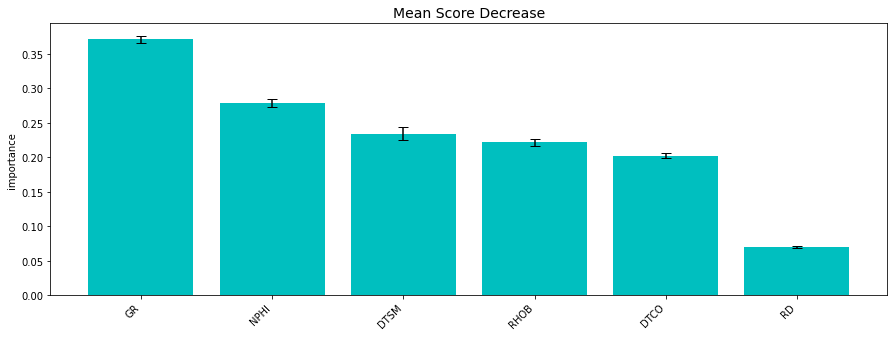

In [ ]:
df_fe = msd(X_train, y_train, model, plot = True, topk=7)

## Fine tuning

In [ ]:
# preprocessor
preprocessor = ColumnTransformer([
                                  ('numeric', num_pipe(scaling= 'standard', poly = 2), X_train.columns.drop(['RS', 'RD']))
])

# final pipeline
pipeline = Pipeline([
                     ('prep', preprocessor),
                     ('algo', RandomForestClassifier(n_jobs=-1, random_state=42))
])

# tuning
model = RandomizedSearchCV(pipeline, rsp.rf_poly_params, cv= 5, n_iter = 50, 
                           n_jobs=-1, verbose=1)
model.fit(X_train, y_train)

print('')                      
print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:  2.8min finished



{'algo__max_depth': 46, 'algo__max_features': 0.7683398923949077, 'algo__min_samples_leaf': 1, 'algo__n_estimators': 136, 'prep__numeric__poly__degree': 1, 'prep__numeric__poly__interaction_only': True}
0.9991652754590985 0.7595911621433542 0.7395659432387313


## Prediction

### Predict training data

In [ ]:
df['Ef_pred'] = model.predict(X)

df.head()

,Depth,Well,Formation,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Electrofacies,Ef_pred
0,4600.0,P-2,Jamieson Fm,66.4510,3.8376,3.6067,13.8882,2.5715,81.8708,NaN,2,2
1,4600.5,P-2,Jamieson Fm,54.4524,4.5844,4.2673,12.1851,2.5604,78.5466,NaN,2,2
2,4601.0,P-2,Jamieson Fm,51.3234,4.9751,4.4704,12.0860,2.5458,81.6343,NaN,2,2
3,4601.5,P-2,Jamieson Fm,49.2121,5.1362,4.6478,11.5609,2.5479,78.2709,NaN,2,2
4,4602.0,P-2,Jamieson Fm,68.4992,4.3777,4.0461,15.9469,2.5307,79.5989,NaN,2,2


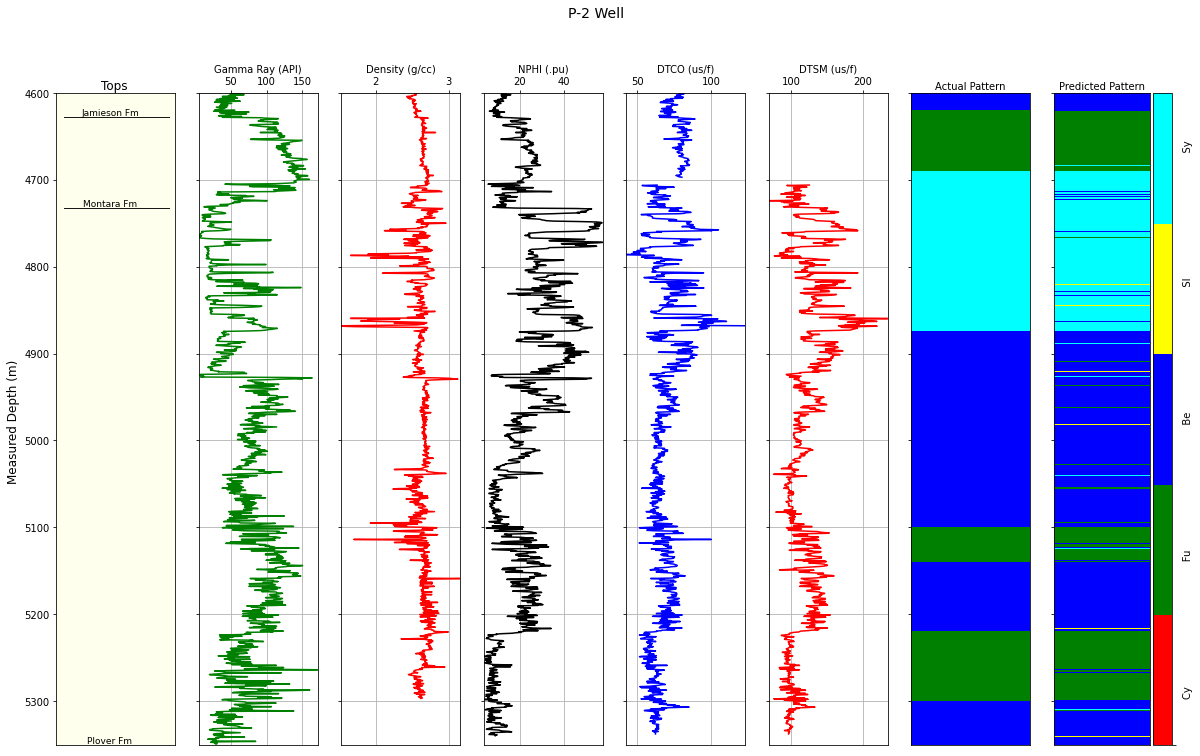

In [ ]:
efplot_val(df, 'P-2')

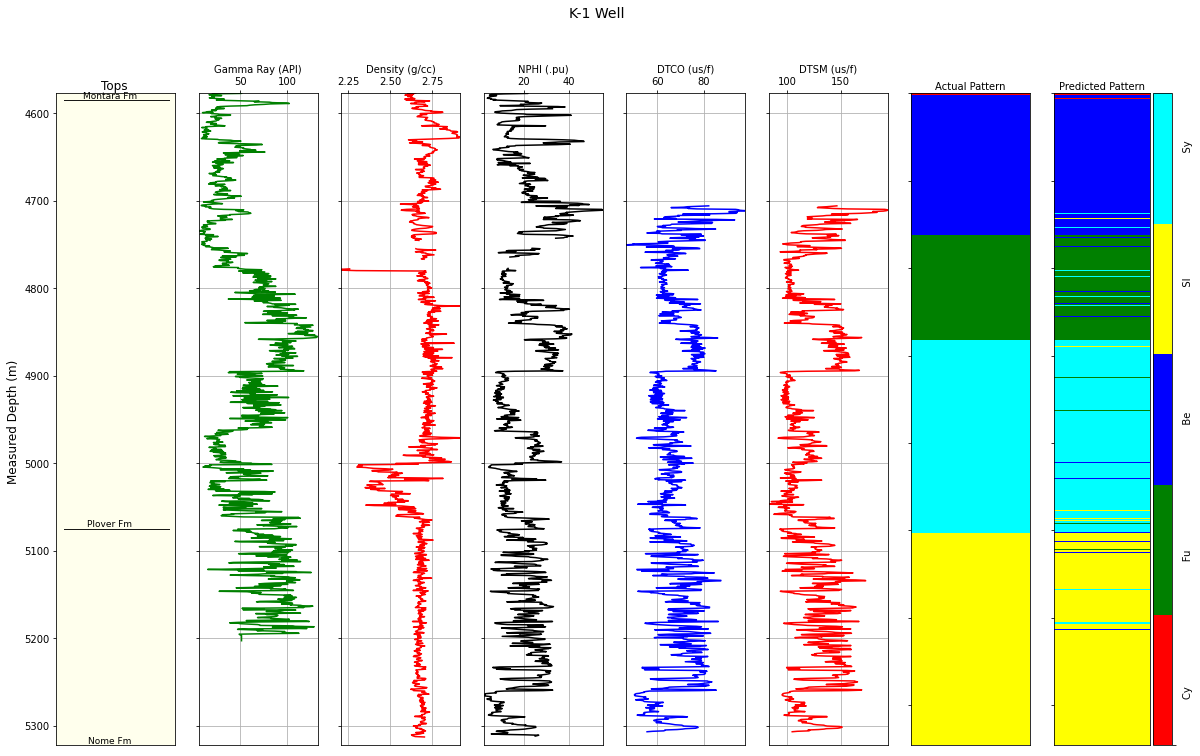

In [ ]:
efplot_val(df, 'K-1')

In [ ]:
# classification report
plot_classification_report(X_train, y_train, X_test, y_test, model, report=True)

Train report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00       496
           2       1.00      1.00      1.00       858
           3       1.00      1.00      1.00       388
           4       1.00      1.00      1.00       648

    accuracy                           1.00      2396
   macro avg       1.00      1.00      1.00      2396
weighted avg       1.00      1.00      1.00      2396


Test report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.78      0.67      0.72       124
           2       0.76      0.85      0.80       215
           3       0.81      0.84      0.82        97
           4       0.79      0.75      0.77       162

    accuracy                           0.78       599
   macro avg       0.63      0.62      0.62       599
weighted avg       0.78      0.78      0.78       5

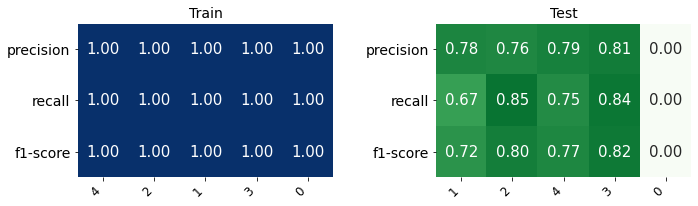

In [ ]:
plot_classification_report(X_train, y_train, X_test, y_test, model)

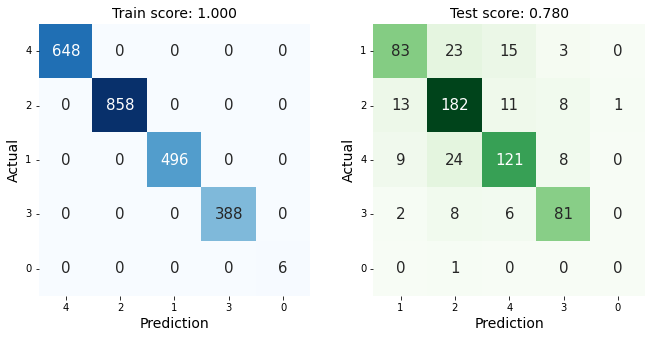

In [ ]:
plot_confusion_matrix(X_train, y_train, X_test, y_test, model)

### Predict testing data

In [ ]:
df_test = pd.read_csv('boreas.csv', index_col= 0)

df_test = df_test.replace([-999.25], np.nan)

df_test = df_test.replace([df_test['GR'].nlargest(3)], np.nan)

df_test.head()

,Depth,Well,Formation,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Ef_pred,Facies_pred,Env_pred
0,4610.0,B-1,Echuca Shoals Fm,55.3259,1.4348,1.4170,12.04,2.6282,87.4786,NaN,2,4,4
1,4610.5,B-1,Echuca Shoals Fm,61.7744,1.1341,1.0694,18.93,2.6688,93.8623,NaN,1,2,4
2,4611.0,B-1,Echuca Shoals Fm,60.9437,1.1748,1.1022,20.12,2.6014,78.9452,NaN,2,2,4
3,4611.5,B-1,Echuca Shoals Fm,67.9765,1.3287,1.2345,20.01,2.6130,64.5839,NaN,3,5,5
4,4612.0,B-1,Echuca Shoals Fm,86.1773,1.0648,1.0360,21.62,2.6041,69.4141,NaN,2,1,2


In [ ]:
df_test.columns

Index(['Depth', 'Well', 'Formation', 'GR', 'RS', 'RD', 'NPHI', 'RHOB', 'DTCO',
       'DTSM', 'Ef_pred', 'Facies_pred', 'Env_pred'],
      dtype='object')

In [ ]:
X_test = pd.DataFrame(df_test.drop(columns= ['Depth', 'Well', 'Formation', 'RS', 'Ef_pred', 'Facies_pred', 'Env_pred']))

X_test.head()

,GR,RD,NPHI,RHOB,DTCO,DTSM
0,55.3259,1.4170,12.04,2.6282,87.4786,NaN
1,61.7744,1.0694,18.93,2.6688,93.8623,NaN
2,60.9437,1.1022,20.12,2.6014,78.9452,NaN
3,67.9765,1.2345,20.01,2.6130,64.5839,NaN
4,86.1773,1.0360,21.62,2.6041,69.4141,NaN


In [ ]:
df_test['Ef_pred'] = model.predict(X_test)

df_test.head()

,Depth,Well,Formation,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Ef_pred,Facies_pred,Env_pred
0,4610.0,B-1,Echuca Shoals Fm,55.3259,1.4348,1.4170,12.04,2.6282,87.4786,NaN,2,4,4
1,4610.5,B-1,Echuca Shoals Fm,61.7744,1.1341,1.0694,18.93,2.6688,93.8623,NaN,2,2,4
2,4611.0,B-1,Echuca Shoals Fm,60.9437,1.1748,1.1022,20.12,2.6014,78.9452,NaN,2,2,4
3,4611.5,B-1,Echuca Shoals Fm,67.9765,1.3287,1.2345,20.01,2.6130,64.5839,NaN,3,5,5
4,4612.0,B-1,Echuca Shoals Fm,86.1773,1.0648,1.0360,21.62,2.6041,69.4141,NaN,2,1,2


In [ ]:
df_test.to_csv()

',Depth,Well,Formation,GR,RS,RD,NPHI,RHOB,DTCO,DTSM,Ef_pred,Facies_pred,Env_pred\n0,4610.0,B-1,Echuca Shoals Fm,55.3259,1.4348,1.4169999999999998,12.04,2.6282,87.4786,,2,4,4\n1,4610.5,B-1,Echuca Shoals Fm,61.7744,1.1341,1.0694,18.93,2.6688,93.8623,,2,2,4\n2,4611.0,B-1,Echuca Shoals Fm,60.9437,1.1748,1.1022,20.12,2.6014,78.9452,,2,2,4\n3,4611.5,B-1,Echuca Shoals Fm,67.9765,1.3287,1.2345,20.01,2.613,64.5839,,3,5,5\n4,4612.0,B-1,Echuca Shoals Fm,86.1773,1.0648,1.036,21.62,2.6041,69.4141,,2,1,2\n5,4612.5,B-1,Echuca Shoals Fm,80.2059,1.3382,1.3263,21.89,2.6021,73.5985,,2,1,2\n6,4613.0,B-1,Echuca Shoals Fm,74.5949,1.6413,1.5482,21.34,2.6164,69.8498,,3,5,5\n7,4613.5,B-1,Echuca Shoals Fm,78.5921,1.3767,1.352,21.31,2.6413,91.6138,,1,1,4\n8,4614.0,B-1,Echuca Shoals Fm,83.1176,1.503,1.4596,20.82,2.6017,85.3235,,1,1,4\n9,4614.5,B-1,Echuca Shoals Fm,51.7665,1.3676,1.3686,20.89,2.5649,88.2898,,2,4,4\n10,4615.0,B-1,Echuca Shoals Fm,41.7301,3.7995,3.6336,17.08,2.6257,87.7482,,1,4,4\n11,4615.5,B-1,Echu

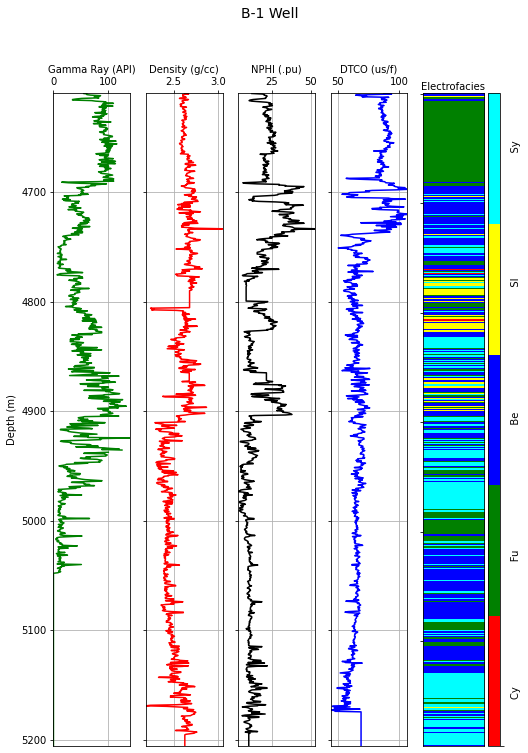

In [ ]:
efplot_test(df_test, 'B-1')

## Save ML model

In [ ]:
save_model(model.best_estimator_, "__________.pkl")

Model is pickled as model/__________.pkl
